# 1 . Data Loading and Preprocessing


In [ ]:
import pandas as pd
df = pd.read_csv("emi_prediction_dataset.csv", dtype={0: str})




In [ ]:
print("Shape:", df.shape)
df.head()


Shape: (404800, 27)


,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [ ]:
# Remove duplicates
df = df.drop_duplicates()



In [ ]:
# Handle missing values
df = df.fillna(df.median(numeric_only=True))


In [ ]:
import pandas as pd
df = pd.read_csv("emi_prediction_dataset.csv", dtype={0: str})
# Encode categorical variables
categorical_cols = ["gender", "marital_status", "education",
                    "employment_type", "company_type",
                    "house_type", "emi_scenario", "existing_loans"]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert all columns in df_encoded to numeric, coercing errors to NaN
# This ensures that columns like 'age' (which might be loaded as string) are handled.
for col in df_encoded.columns:
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')

# Fill any NaN values that might have been introduced by the coercion
# with the median of the respective columns.
df_encoded = df_encoded.fillna(df_encoded.median(numeric_only=True))

df_encoded.head() # Ensure df_encoded is created and clean

,age,monthly_salary,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,...,company_type_Mid-size,company_type_Small,company_type_Startup,house_type_Own,house_type_Rented,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI,existing_loans_Yes
0,38.0,82600.0,0.9,20000.0,3,2,0.0,0.0,7200.0,19500.0,...,True,False,False,False,True,False,False,True,False,True
1,38.0,21500.0,7.0,0.0,2,1,5100.0,0.0,1400.0,5400.0,...,False,False,False,False,False,False,False,False,False,True
2,38.0,86100.0,5.8,0.0,4,3,0.0,0.0,10200.0,19400.0,...,False,False,True,True,False,True,False,False,False,False
3,58.0,66800.0,2.2,0.0,5,4,11400.0,0.0,6200.0,11900.0,...,True,False,False,True,False,False,False,False,True,False
4,48.0,57300.0,3.4,0.0,4,3,9400.0,21300.0,3600.0,16200.0,...,True,False,False,False,False,False,True,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

# Ensure the original 'existing_loans' column (if it somehow persisted as a string column)
# is dropped before creating X, to avoid issues with pd.to_numeric later.
if 'existing_loans' in df_encoded.columns and df_encoded['existing_loans'].dtype == 'object':
    X = df_encoded.drop(["emi_eligibility", "max_monthly_emi", "existing_loans"], axis=1)
else:
    X = df_encoded.drop(["emi_eligibility", "max_monthly_emi"], axis=1)

y_class = df_encoded["emi_eligibility"]
y_reg = df_encoded["max_monthly_emi"]

X_train, X_temp, y_class_train, y_class_temp = train_test_split(X, y_class, test_size=0.3, random_state=42)
X_val, X_test, y_class_val, y_class_test = train_test_split(X_temp, y_class_temp, test_size=0.5, random_state=42)

_, _, y_reg_train, y_reg_temp = train_test_split(X, y_reg, test_size=0.3, random_state=42)
y_reg_val, y_reg_test = train_test_split(y_reg_temp, test_size=0.5, random_state=42)

# 2.Exploratory Data Analysis (EDA)




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



Text(0.5, 1.0, 'EMI Eligibility Distribution')

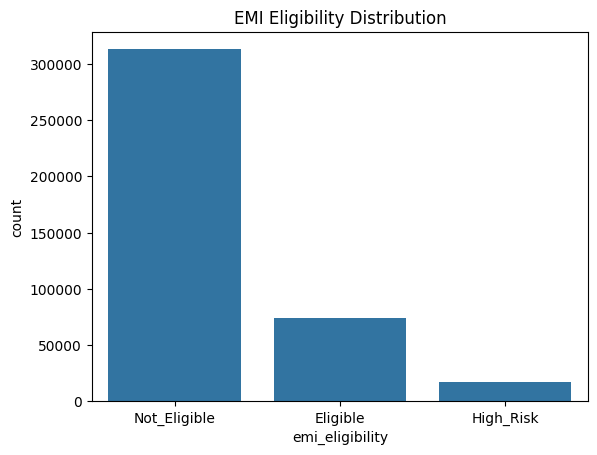

In [ ]:
# EMI eligibility distribution
sns.countplot(x="emi_eligibility", data=df)
plt.title("EMI Eligibility Distribution")



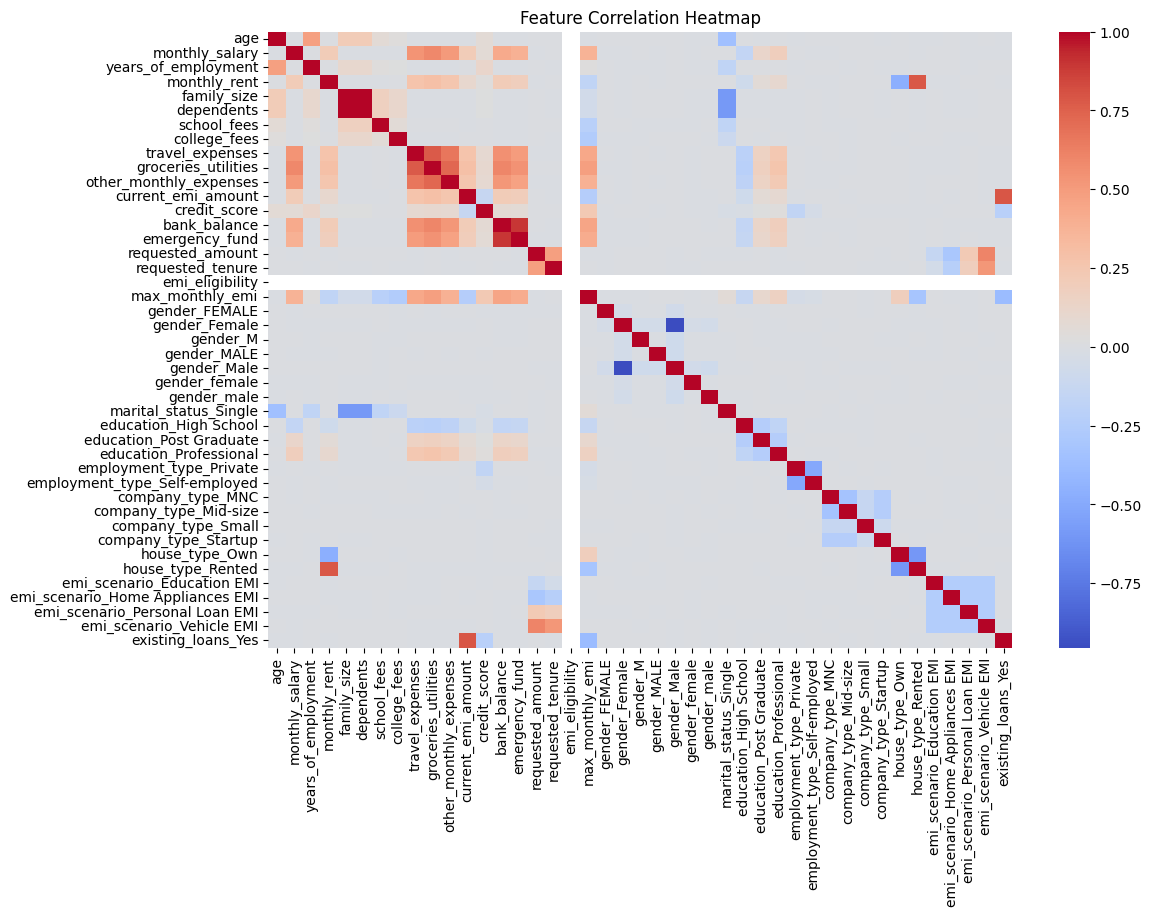

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(12,8))

# Convert all columns to numeric, coercing errors to NaN
for col in df_encoded.columns:
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce')

# Fill any NaN values that might have been introduced by the coercion
# with the median of the respective columns.
df_encoded = df_encoded.fillna(df_encoded.median(numeric_only=True))

sns.heatmap(df_encoded.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# 3.feature engineering

In [ ]:
# Derived ratios
# Ensure columns are numeric before calculations
numeric_cols = ["current_emi_amount", "monthly_salary", "groceries_utilities",
                "other_monthly_expenses", "requested_amount", "requested_tenure"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill NaN values that might have been introduced by coercion
df = df.fillna(df.median(numeric_only=True))

df["debt_to_income"] = df["current_emi_amount"] / df["monthly_salary"]
df["expense_to_income"] = (df["groceries_utilities"] + df["other_monthly_expenses"]) / df["monthly_salary"]
df["affordability_ratio"] = df["requested_amount"] / (df["monthly_salary"] * df["requested_tenure"])

# Update encoded dataset
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
# Update encoded dataset
df_encoded = pd.get_dummies(df, drop_first=True)


#4. Classification Models




In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

models_class = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="mlogloss")
}


## 5.Regression models

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

models_reg = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBoost Regressor": XGBRegressor()
}


# 6.MLflow integration

In [ ]:
pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existi

In [ ]:
import mlflow

mlflow.set_experiment("EMIPredictAI")

<Experiment: artifact_location='/content/mlruns/2', creation_time=1771425796699, experiment_id='2', last_update_time=1771425796699, lifecycle_stage='active', name='EMIPredictAI', tags={}>

In [ ]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("EMIPredictAI")



<Experiment: artifact_location='/content/mlruns/2', creation_time=1771425796699, experiment_id='2', last_update_time=1771425796699, lifecycle_stage='active', name='EMIPredictAI', tags={}>

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import mlflow
import mlflow.sklearn



# 7.streamlit app

In [ ]:
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models_class = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="mlogloss")
}

# Save best models
pickle.dump(models_class["Random Forest"], open("classification_model.pkl", "wb"))
pickle.dump(models_reg["Random Forest Regressor"], open("regression_model.pkl", "wb"))

In [ ]:
# Create Streamlit app
with open("streamlit_app.py", "w") as f:
    f.write("""
import streamlit as st
import pickle
import numpy as np

clf_model = pickle.load(open("classification_model.pkl", "rb"))
reg_model = pickle.load(open("regression_model.pkl", "rb"))

st.title("EMIPredict AI - Financial Risk Assessment")

income = st.number_input("Monthly Income", min_value=1000, step=500)
expenses = st.number_input("Monthly Expenses", min_value=0, step=100)
loan_amount = st.number_input("Loan Amount", min_value=10000, step=5000)

features = np.array([[income, expenses, loan_amount]])
eligibility = clf_model.predict(features)[0]
safe_emi = reg_model.predict(features)[0]

st.write("### Results")
st.write(f"Loan Eligibility: {eligibility}")
st.write(f"Maximum Safe EMI: ₹{safe_emi:.2f}")
""")


# 8.run streamlit in colab

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 37.4 MB/s eta 0:00:00
